# Descriptive Analysis — Heart-Rate Zones & Per-Patient Glucose

Two questions answered from `data/Team01_PYVoyagers_cleaned_data.csv` (5-min CGM + Fitbit + pump series joined to demographics in `data/Cleaned_demographics.csv`).

**Q1 — HR zones vs glucose.** Does cardiovascular load (resting / moderate / high) move blood glucose, and by how much?
**Q2 — Per-patient glucose.** How does average glucose vary across the cohort, and which demographic factors line up with it?

## 1. Setup & Load

In [1]:
# =========================================================
# LIBRARIES
# =========================================================

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 100


# =========================================================
# DATA LOADING
# =========================================================

DATA = Path('data')

df = pd.read_csv(
    DATA / 'Team01_PYVoyagers_cleaned_data.csv',
    parse_dates=['time']
)

demo = pd.read_csv(DATA / 'Cleaned_demographics.csv')


# =========================================================
# CLINICAL THRESHOLDS (mg/dL)
# =========================================================

HYPO = 70
HYPER = 180
TIR_RANGE = (70, 180)


# =========================================================
# DATA PREPARATION
# =========================================================

df = df.sort_values(['patient_id', 'time']).reset_index(drop=True)


# =========================================================
# DATA QUALITY CHECKS
# =========================================================

print("=================================================")
print("COHORT OVERVIEW - DATA SUMMARY")
print("=================================================\n")

print(f"Records      : {len(df):,}")
print(f"Patients     : {df['patient_id'].nunique()}")
print(f"Demographics : {demo['patient_id'].nunique()} patients")

print(
    f"Date range   : {df['time'].min().date()} → {df['time'].max().date()}"
)


# Missing values check (important for hackathon credibility)
print("\nMissing values (top 10 columns):")
print(df.isna().sum().sort_values(ascending=False).head(10))


COHORT OVERVIEW - DATA SUMMARY

Records      : 309,392
Patients     : 25
Demographics : 25 patients
Date range   : 2018-06-13 → 2022-05-18

Missing values (top 10 columns):
time                      0
glucose                   0
calories                  0
heart_rate                0
steps                     0
basal_rate                0
bolus_volume_delivered    0
carb_input                0
patient_id                0
age                       0
dtype: int64


**Columns I'm going to use, and why:**

| Column | Why it matters |
|---|---|
| `glucose` | Outcome — every chart compares against this |
| `heart_rate` | Direct measure of cardiovascular load; muscle glucose uptake (GLUT4 translocation) is HR/intensity-dependent |
| `patient_id` | Glucose baselines vary 50+ mg/dL between people; nothing is meaningful without per-patient normalization |
| `age` | Used to compute age-predicted HR-max (220 − age), so the same `bpm` value means different intensity for a 20- vs 70-year-old |
| `gender`, `average_sleep_duration_hrs`, `sleep_quality_1_10` | Demographic stratifiers for Q2 |
| `time` | Lets us sample correctly over the day and ignore sensor warm-up periods |

**Columns I'm deliberately NOT using here:** `calories`, `steps`, `basal_rate`, `bolus_volume_delivered`, `carb_input` — these are confounders for Q1 and target columns for other notebooks; mixing them in would muddy the HR-zone effect.

## 2. Cohort overview

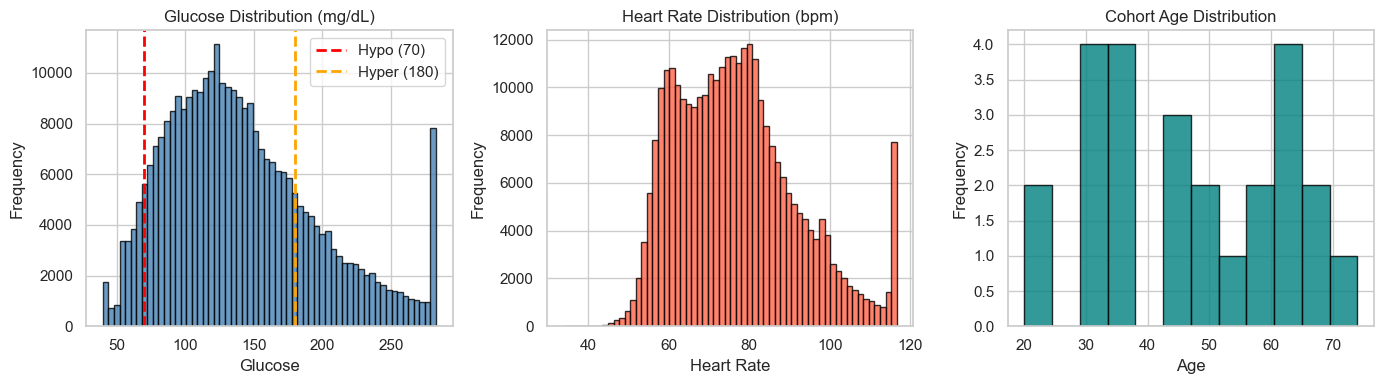

Glucose:    mean = 140.7   std = 54.8   median = 132.0
Heart rate: mean = 76.8   std = 15.1   median = 75.4


In [2]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# ---------------- GLUCOSE ----------------
axes[0].hist(
    df['glucose'].dropna(),
    bins=60,
    color='steelblue',
    edgecolor='black',
    alpha=0.8
)

axes[0].axvline(
    HYPO,
    color='red',
    linestyle='--',
    linewidth=2,
    label='Hypo (70)'
)

axes[0].axvline(
    HYPER,
    color='orange',
    linestyle='--',
    linewidth=2,
    label='Hyper (180)'
)

axes[0].set_title('Glucose Distribution (mg/dL)', fontsize=12)
axes[0].set_xlabel('Glucose')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# ---------------- HEART RATE ----------------
axes[1].hist(
    df['heart_rate'].dropna(),
    bins=60,
    color='tomato',
    edgecolor='black',
    alpha=0.8
)

axes[1].set_title('Heart Rate Distribution (bpm)', fontsize=12)
axes[1].set_xlabel('Heart Rate')
axes[1].set_ylabel('Frequency')

# ---------------- COHORT AGE ----------------
demo['age'].plot.hist(
    bins=12,
    ax=axes[2],
    color='teal',
    edgecolor='black',
    alpha=0.8
)

axes[2].set_title('Cohort Age Distribution', fontsize=12)
axes[2].set_xlabel('Age')
axes[2].set_ylabel('Frequency')

# ---------------- FINAL LAYOUT ----------------
plt.tight_layout()
plt.show()

# ---------------- SUMMARY STATISTICS ----------------
print(
    'Glucose:    mean = {:.1f}   std = {:.1f}   median = {:.1f}'.format(
        df.glucose.mean(),
        df.glucose.std(),
        df.glucose.median()
    )
)

print(
    'Heart rate: mean = {:.1f}   std = {:.1f}   median = {:.1f}'.format(
        df.heart_rate.mean(),
        df.heart_rate.std(),
        df.heart_rate.median()
    )
)

## 3. Q1 — Heart-Rate Zones vs Glucose

### 3.1 Defining zones — two complementary cuts

**Absolute bpm zones** (clinically intuitive, comparable across studies):
- Resting: `< 80 bpm`
- Moderate: `80 – 110 bpm`
- High: `≥ 110 bpm`

**Age-adjusted %HRmax zones** (fairer across ages because HR-max declines ~1 bpm/year). Using the standard formula `HRmax = 220 − age`:
- Resting/Light: `< 50 %HRmax`
- Moderate: `50 – 70 %HRmax`
- High: `≥ 70 %HRmax`

We compute both and let the reader compare. Without the age-adjusted version, a 67-year-old at 95 bpm is misclassified as “moderate” when they're actually pushing 70 %HRmax.

In [3]:
df['hr_zone_bpm'] = pd.cut(df['heart_rate'],
                            bins=[0, 80, 110, 300],
                            labels=['Resting (<80)', 'Moderate (80-110)', 'High (≥110)'])

df['hr_max']     = 220 - df['age']
df['hr_pct_max'] = df['heart_rate'] / df['hr_max'] * 100
df['hr_zone_pct'] = pd.cut(df['hr_pct_max'],
                            bins=[0, 50, 70, 200],
                            labels=['Resting/Light (<50%)', 'Moderate (50-70%)', 'High (≥70%)'])

print('Sample counts per zone:')
print(pd.concat([df['hr_zone_bpm'].value_counts().rename('absolute_bpm'),
                 df['hr_zone_pct'].value_counts().rename('age_adjusted')], axis=1))

Sample counts per zone:
                      absolute_bpm  age_adjusted
Resting (<80)             192568.0           NaN
Moderate (80-110)         105125.0           NaN
High (≥110)                11699.0           NaN
Resting/Light (<50%)           NaN      214967.0
Moderate (50-70%)              NaN       84903.0
High (≥70%)                    NaN        9522.0


### 3.2 Glucose distribution by HR zone (cohort-level)

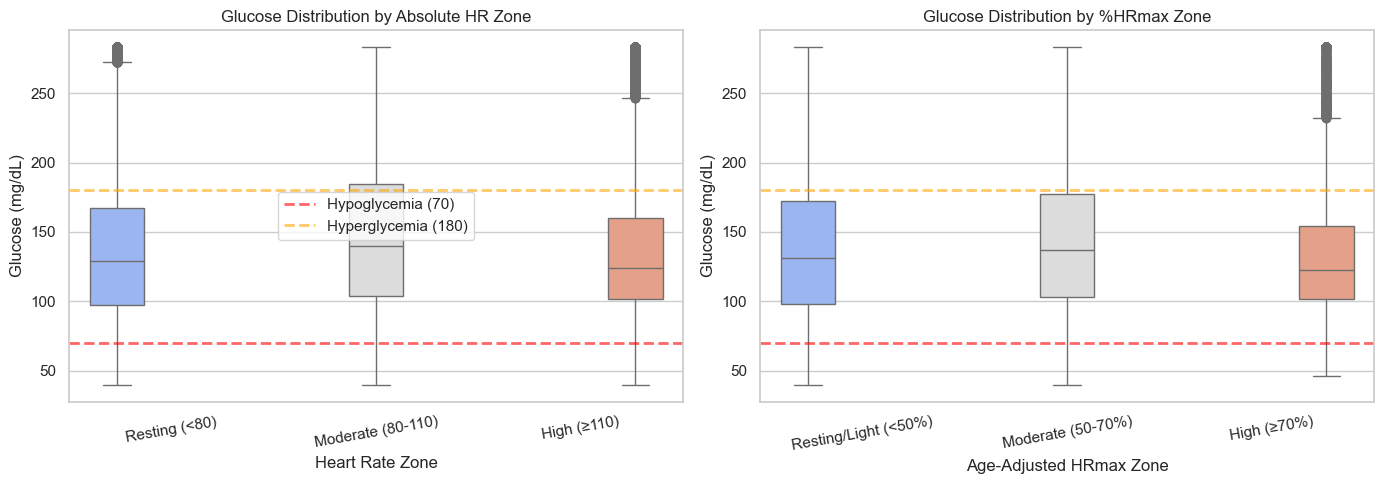

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# =========================================================
# BOXPLOT 1: Glucose vs Absolute Heart Rate Zones
# =========================================================
sns.boxplot(
    data=df.dropna(subset=['hr_zone_bpm']),
    x='hr_zone_bpm',
    y='glucose',
    ax=axes[0],
    order=[
        'Resting (<80)',
        'Moderate (80-110)',
        'High (≥110)'
    ],
    hue='hr_zone_bpm',      # avoids seaborn future warning
    palette='coolwarm',
    legend=False
)

# Clinical threshold lines
axes[0].axhline(
    HYPO,
    color='red',
    linestyle='--',
    alpha=0.6,
    linewidth=2,
    label='Hypoglycemia (70)'
)

axes[0].axhline(
    HYPER,
    color='orange',
    linestyle='--',
    alpha=0.6,
    linewidth=2,
    label='Hyperglycemia (180)'
)

axes[0].set_title(
    'Glucose Distribution by Absolute HR Zone',
    fontsize=12
)

axes[0].set_xlabel('Heart Rate Zone')
axes[0].set_ylabel('Glucose (mg/dL)')
axes[0].tick_params(axis='x', rotation=10)
axes[0].legend()


# =========================================================
# BOXPLOT 2: Glucose vs Age-Adjusted HRmax %
# =========================================================
sns.boxplot(
    data=df.dropna(subset=['hr_zone_pct']),
    x='hr_zone_pct',
    y='glucose',
    ax=axes[1],
    order=[
        'Resting/Light (<50%)',
        'Moderate (50-70%)',
        'High (≥70%)'
    ],
    hue='hr_zone_pct',
    palette='coolwarm',
    legend=False
)

# Clinical threshold lines
axes[1].axhline(
    HYPO,
    color='red',
    linestyle='--',
    alpha=0.6,
    linewidth=2
)

axes[1].axhline(
    HYPER,
    color='orange',
    linestyle='--',
    alpha=0.6,
    linewidth=2
)

axes[1].set_title(
    'Glucose Distribution by %HRmax Zone',
    fontsize=12
)

axes[1].set_xlabel('Age-Adjusted HRmax Zone')
axes[1].set_ylabel('Glucose (mg/dL)')
axes[1].tick_params(axis='x', rotation=10)

# =========================================================
# FINAL LAYOUT
# =========================================================
plt.tight_layout()
plt.show()

In [5]:
# =========================================================
# SUMMARY STATISTICS: Glucose by Age-Adjusted HR Zone
# =========================================================

summary = (
    df.dropna(subset=['hr_zone_pct'])
      .groupby('hr_zone_pct')['glucose']
      .agg(['count', 'mean', 'std', 'median'])
      .round(1)
)

print('Glucose Summary Statistics by Age-Adjusted HR Zone:')
print(summary)


# =========================================================
# ONE-WAY ANOVA TEST
# Tests whether mean glucose differs across HR zones
# =========================================================

groups = [
    g['glucose'].dropna().to_numpy()
    for _, g in df.dropna(subset=['hr_zone_pct'])
                  .groupby('hr_zone_pct')
    if len(g) > 1
]

# Perform ANOVA only if at least 2 valid groups exist
if len(groups) >= 2:

    f_stat, p_value = stats.f_oneway(*groups)

    print('\nOne-Way ANOVA Across HR Zones')
    print(f'F-statistic = {f_stat:.2f}')
    print(f'p-value     = {p_value:.2e}')

    # Basic interpretation
    if p_value < 0.05:
        print('Result: Significant difference in mean glucose across HR zones.')
    else:
        print('Result: No statistically significant difference across HR zones.')

Glucose Summary Statistics by Age-Adjusted HR Zone:
                       count   mean   std  median
hr_zone_pct                                      
Resting/Light (<50%)  214967  139.6  55.2   131.0
Moderate (50-70%)      84903  144.4  54.4   137.0
High (≥70%)             9522  131.5  46.2   122.3

One-Way ANOVA Across HR Zones
F-statistic = 371.06
p-value     = 1.10e-161
Result: Significant difference in mean glucose across HR zones.


### 3.3 Within-patient effect (the cohort effect can be Simpson's-paradox'd)

If patient A is mostly sedentary with high glucose and patient B exercises a lot with lower glucose, a cohort boxplot will show "high HR → lower glucose" even when no patient personally experiences that. The within-patient view fixes this by computing each patient's own zone means.

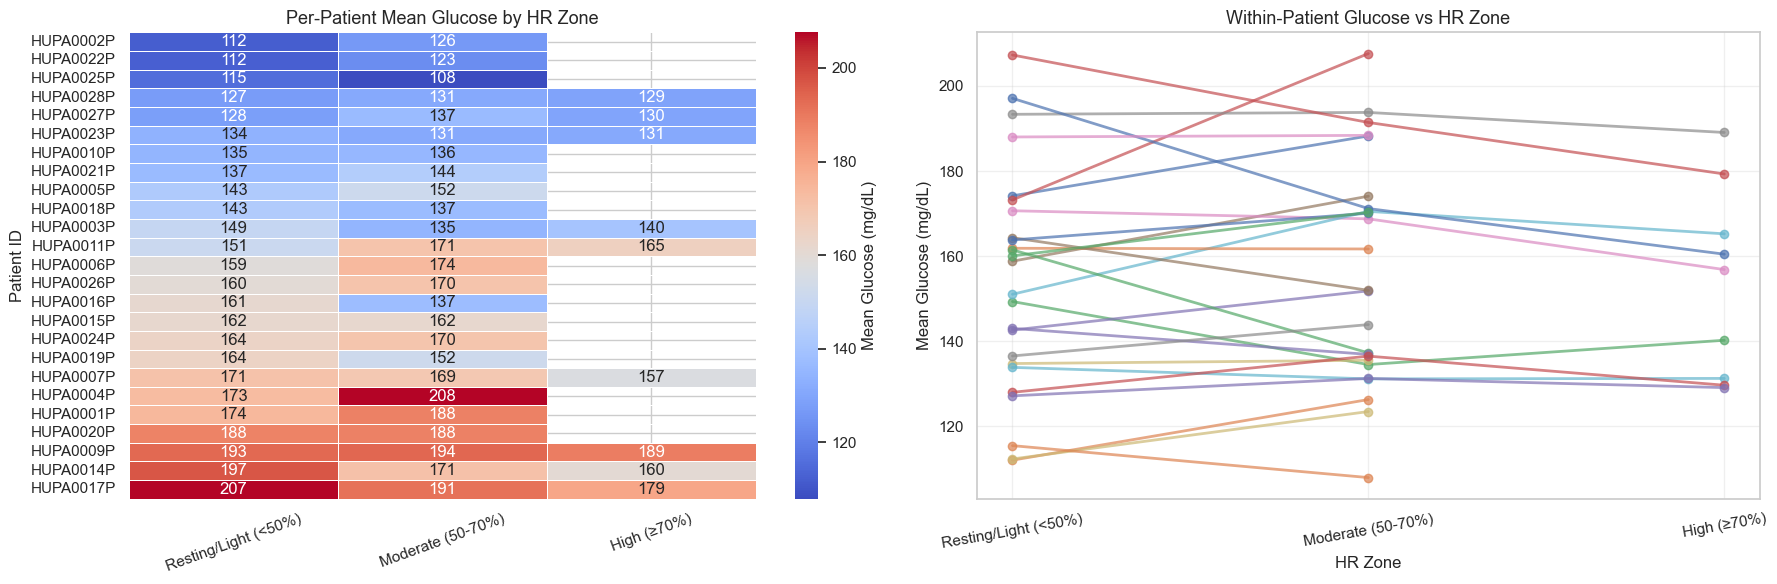

Per-patient (high − resting) glucose delta:
patient_id
HUPA0001P     NaN
HUPA0002P     NaN
HUPA0003P    -9.1
HUPA0004P     NaN
HUPA0005P     NaN
HUPA0006P     NaN
HUPA0007P   -13.8
HUPA0009P    -4.3
HUPA0010P     NaN
HUPA0011P    14.2
HUPA0014P   -36.6
HUPA0015P     NaN
HUPA0016P     NaN
HUPA0017P   -28.0
HUPA0018P     NaN
HUPA0019P     NaN
HUPA0020P     NaN
HUPA0021P     NaN
HUPA0022P     NaN
HUPA0023P    -2.6
HUPA0024P     NaN
HUPA0025P     NaN
HUPA0026P     NaN
HUPA0027P     1.7
HUPA0028P     1.9

Cohort mean delta: -8.5 mg/dL    median: -4.3 mg/dL


In [6]:
wp = (
    df.dropna(subset=['hr_zone_pct'])
      .groupby(['patient_id', 'hr_zone_pct'])['glucose']
      .mean()
      .unstack()
)

# Reorder columns
wp = wp[
    ['Resting/Light (<50%)',
     'Moderate (50-70%)',
     'High (≥70%)']
]

# Bigger figure
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# ---------------- HEATMAP ----------------
sns.heatmap(
    wp.sort_values('Resting/Light (<50%)'),
    annot=True,
    fmt='.0f',
    cmap='coolwarm',
    linewidths=0.5,
    cbar_kws={'label': 'Mean Glucose (mg/dL)'},
    ax=axes[0]
)

axes[0].set_title('Per-Patient Mean Glucose by HR Zone', fontsize=13)
axes[0].set_xlabel('')
axes[0].set_ylabel('Patient ID')

# Rotate x labels slightly
axes[0].tick_params(axis='x', rotation=20)

# ---------------- LINE PLOT ----------------
for pid, row in wp.iterrows():
    axes[1].plot(
        row.index,
        row.values,
        marker='o',
        linewidth=2,
        alpha=0.7
    )

axes[1].set_title('Within-Patient Glucose vs HR Zone', fontsize=13)
axes[1].set_ylabel('Mean Glucose (mg/dL)')
axes[1].set_xlabel('HR Zone')

# Better spacing for labels
axes[1].tick_params(axis='x', rotation=10)

# Optional grid
axes[1].grid(True, alpha=0.3)

# REMOVE LEGEND if too many patients
# axes[1].legend(...)

plt.tight_layout()
plt.show()

# ---------------- DELTA ----------------
delta = (
    wp['High (≥70%)']
    - wp['Resting/Light (<50%)']
).rename('high − rest (mg/dL)')

print('Per-patient (high − resting) glucose delta:')
print(delta.round(1).to_string())

print(
    f'\nCohort mean delta: {delta.mean():.1f} mg/dL'
    f'    median: {delta.median():.1f} mg/dL'
)

**Read this delta carefully.** A negative delta (high − rest < 0) means "glucose is lower while exercising than at rest" — the expected and clinically desired direction. A positive delta usually flags either (a) carb intake right before activity, (b) stress hormone response, or (c) too few high-zone samples to be reliable.

## 4. Q2 — Average Glucose by Patient

In [7]:
# =========================================================
# PATIENT-LEVEL GLUCOSE SUMMARY METRICS
# =========================================================

import numpy as np
import pandas as pd

# =========================================================
# CLINICAL THRESHOLDS (mg/dL)
# =========================================================

HYPO = 70
HYPER = 180


# =========================================================
# PATIENT-LEVEL AGGREGATION
# =========================================================

per_pt = (
    df.groupby('patient_id')['glucose']
      .agg([
          'mean',
          'std',
          'median',

          # Time in Range (TIR: 70–180 mg/dL)
          (
              'tir',
              lambda x: (
                  ((x >= HYPO) & (x <= HYPER)).mean() * 100
              )
          ),

          # Time Below Range (TBR: <70 mg/dL)
          (
              'tbr',
              lambda x: (
                  (x < HYPO).mean() * 100
              )
          ),

          # Time Above Range (TAR: >180 mg/dL)
          (
              'tar',
              lambda x: (
                  (x > HYPER).mean() * 100
              )
          ),

          # Number of readings per patient
          ('n', 'size')
      ])
      .round(2)
)


# =========================================================
# MERGE WITH DEMOGRAPHICS
# =========================================================

per_pt = (
    per_pt.merge(
        demo[
            [
                'patient_id',
                'age',
                'gender',
                'average_sleep_duration_hrs',
                'sleep_quality_1_10'
            ]
        ],
        left_index=True,
        right_on='patient_id'
    )
    .set_index('patient_id')
)


# =========================================================
# SORT BY MEAN GLUCOSE (RISK INDICATOR)
# =========================================================

per_pt = per_pt.sort_values('mean', ascending=False)


# =========================================================
# FINAL OUTPUT TABLE
# =========================================================

cols_to_show = [
    'mean',
    'std',
    'median',
    'tir',
    'tbr',
    'tar',
    'age',
    'gender',
    'average_sleep_duration_hrs',
    'sleep_quality_1_10'
]

print("\n=================================================")
print("PATIENT-LEVEL GLUCOSE SUMMARY TABLE")
print("=================================================\n")

print(per_pt[cols_to_show])


PATIENT-LEVEL GLUCOSE SUMMARY TABLE

              mean    std  median    tir    tbr    tar  age  gender  \
patient_id                                                            
HUPA0017P   197.63  64.36  207.00  35.70   2.39  61.91   64  Female   
HUPA0009P   193.53  45.67  192.00  41.45   0.00  58.55   65  Female   
HUPA0020P   188.04  68.53  185.17  44.76   3.56  51.68   29    Male   
HUPA0014P   184.43  65.64  184.00  44.06   4.05  51.89   56    Male   
HUPA0001P   176.55  60.10  165.67  56.49   1.44  42.07   34    Male   
HUPA0004P   175.47  74.34  171.67  44.82   9.70  45.48   34  Female   
HUPA0007P   169.89  72.68  170.33  45.86   8.94  45.19   67    Male   
HUPA0024P   165.66  63.74  171.00  48.38   7.79  43.83   53    Male   
HUPA0015P   161.84  64.42  150.33  58.68   4.17  37.16   33  Female   
HUPA0019P   161.56  57.22  157.00  62.38   2.69  34.92   46    Male   
HUPA0026P   161.53  65.33  157.33  53.54   7.71  38.75   33    Male   
HUPA0006P   159.68  73.69  146.00  56.0

**Why these are the right summary columns:**
- `mean` / `median` — central tendency, the headline answer to the question.
- `std` — dispersion; two patients with the same mean glucose can have very different variability and risk profiles.
- `tir` (Time-In-Range 70–180) — the standard clinical target (>70%); a single number that aligns with diabetes guidelines.
- `tbr` / `tar` — Time-Below-Range and Time-Above-Range break the tail risks apart; tbr is the more dangerous one acutely.

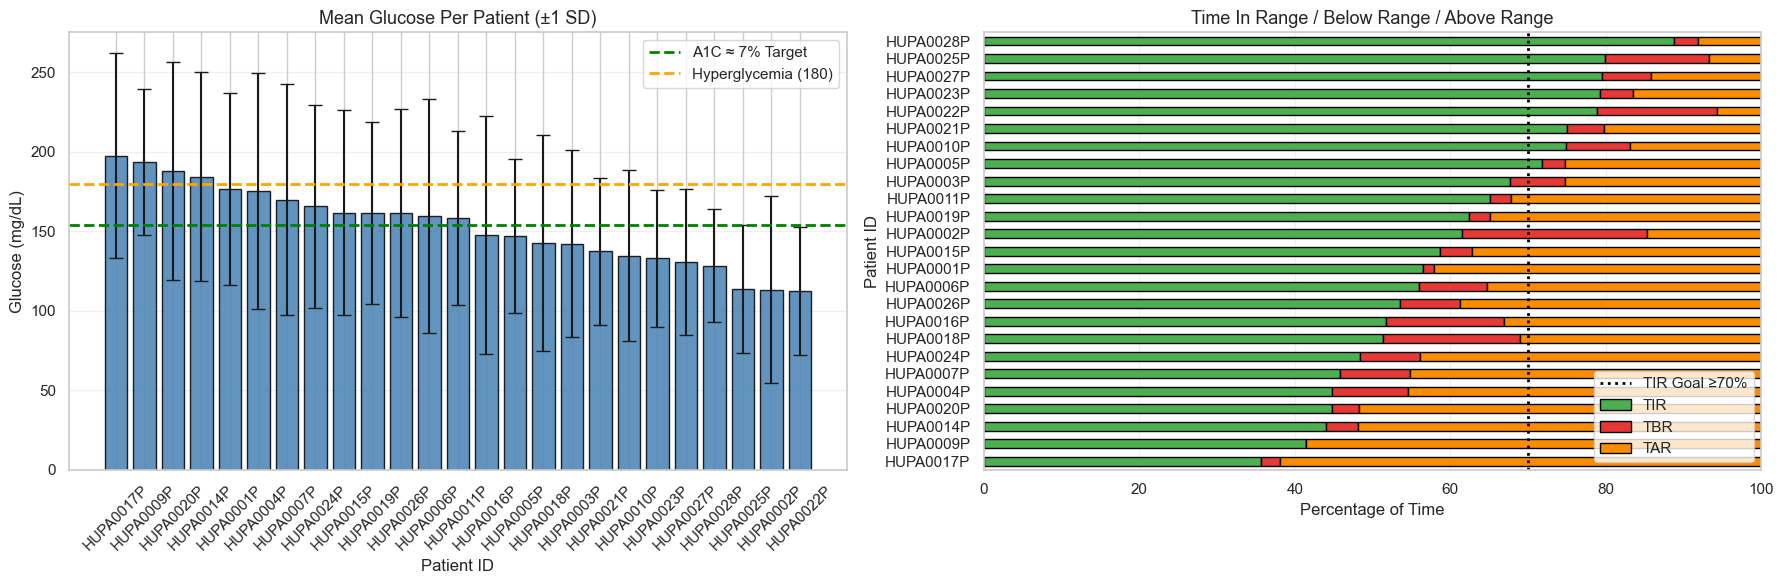

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# =========================================================
# CHART 1: Mean Glucose Per Patient
# =========================================================

axes[0].bar(
    per_pt.index.astype(str),
    per_pt['mean'],
    yerr=per_pt['std'],
    capsize=5,
    color='steelblue',
    edgecolor='black',
    alpha=0.85
)

# Clinical reference lines
axes[0].axhline(
    154,
    color='green',
    linestyle='--',
    linewidth=2,
    label='A1C ≈ 7% Target'
)

axes[0].axhline(
    HYPER,
    color='orange',
    linestyle='--',
    linewidth=2,
    label='Hyperglycemia (180)'
)

axes[0].set_title(
    'Mean Glucose Per Patient (±1 SD)',
    fontsize=13
)

axes[0].set_ylabel('Glucose (mg/dL)')
axes[0].set_xlabel('Patient ID')

# Better x-label readability
axes[0].tick_params(axis='x', rotation=45)

# Add light grid
axes[0].grid(axis='y', alpha=0.3)

axes[0].legend()


# =========================================================
# CHART 2: TIR / TBR / TAR
# =========================================================

tir_sorted = (
    per_pt[['tir', 'tbr', 'tar']]
    .sort_values('tir', ascending=True)
)

tir_sorted.plot(
    kind='barh',
    stacked=True,
    ax=axes[1],
    color=['#4caf50', '#e53935', '#fb8c00'],
    edgecolor='black'
)

# Target line
axes[1].axvline(
    70,
    color='black',
    linestyle=':',
    linewidth=2,
    label='TIR Goal ≥ 70%'
)

axes[1].set_xlim(0, 100)

axes[1].set_xlabel('Percentage of Time')
axes[1].set_ylabel('Patient ID')

axes[1].set_title(
    'Time In Range / Below Range / Above Range',
    fontsize=13
)

# Cleaner legend placement
axes[1].legend(
    ['TIR Goal ≥70%', 'TIR', 'TBR', 'TAR'],
    loc='lower right'
)

# Light grid
axes[1].grid(axis='x', alpha=0.3)

# =========================================================
# FINAL LAYOUT
# =========================================================

plt.tight_layout()
plt.show()

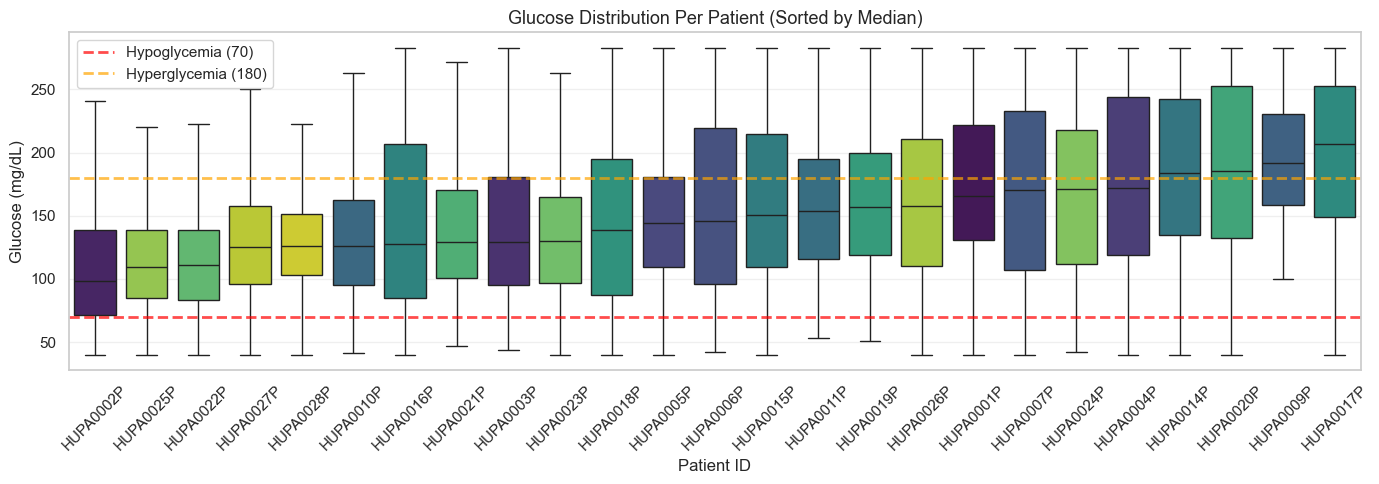

In [9]:
# =========================================================
# FULL GLUCOSE DISTRIBUTION PER PATIENT
# Patients sorted by median glucose level
# =========================================================

fig, ax = plt.subplots(figsize=(14, 5))

# Sort patients by median glucose
order = (
    per_pt.sort_values('median')
          .index
          .tolist()
)

# Boxplot
sns.boxplot(
    data=df,
    x='patient_id',
    y='glucose',
    order=order,
    ax=ax,
    hue='patient_id',      # avoids seaborn future warning
    palette='viridis',
    showfliers=False,
    legend=False
)

# Clinical threshold lines
ax.axhline(
    HYPO,
    color='red',
    linestyle='--',
    alpha=0.7,
    linewidth=2,
    label='Hypoglycemia (70)'
)

ax.axhline(
    HYPER,
    color='orange',
    linestyle='--',
    alpha=0.7,
    linewidth=2,
    label='Hyperglycemia (180)'
)

# Titles and labels
ax.set_title(
    'Glucose Distribution Per Patient (Sorted by Median)',
    fontsize=13
)

ax.set_xlabel('Patient ID')
ax.set_ylabel('Glucose (mg/dL)')

# Improve label readability
ax.tick_params(axis='x', rotation=45)

# Light grid for readability
ax.grid(axis='y', alpha=0.3)

ax.legend()

plt.tight_layout()
plt.show()

### 4.1 Does demographic context explain the spread?

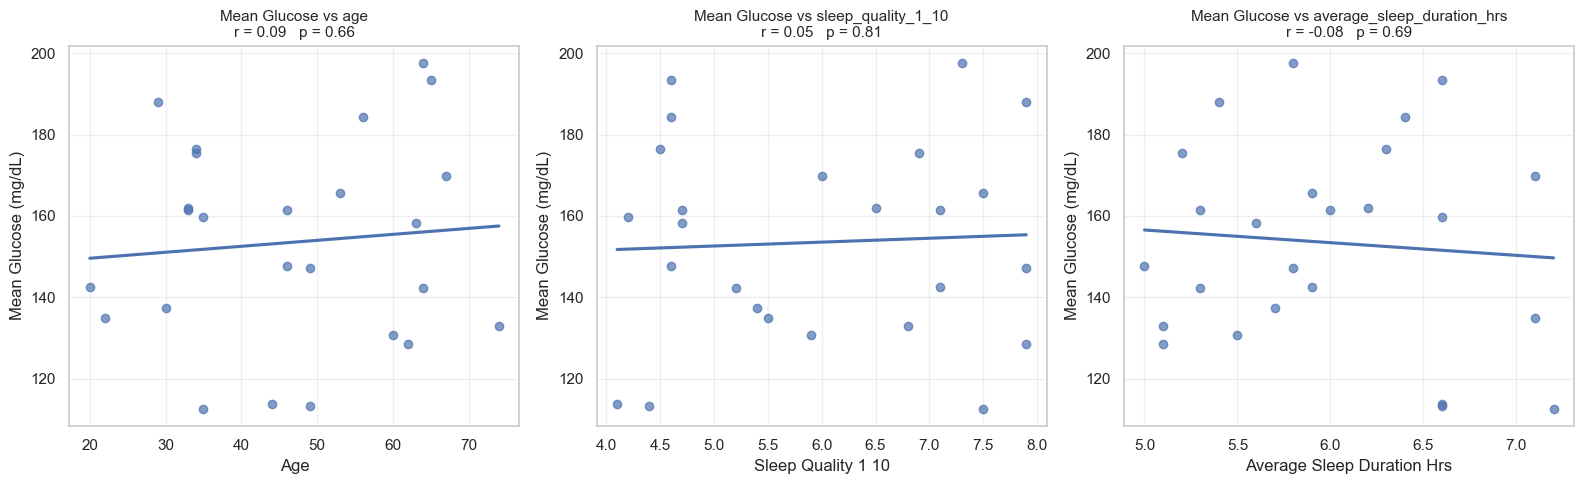

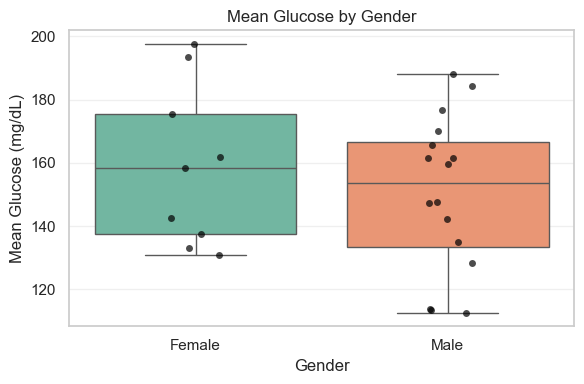

In [10]:
# =========================================================
# CORRELATION ANALYSIS:
# Mean Glucose vs Clinical / Lifestyle Features
# =========================================================

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

features = [
    'age',
    'sleep_quality_1_10',
    'average_sleep_duration_hrs'
]

for ax, feature in zip(axes, features):

    # Regression plot
    sns.regplot(
        data=per_pt.reset_index(),
        x=feature,
        y='mean',
        ax=ax,
        ci=None,
        scatter_kws={'alpha': 0.7}
    )

    # Pearson correlation
    r, p = stats.pearsonr(
        per_pt[feature],
        per_pt['mean']
    )

    # Chart title with statistics
    ax.set_title(
        f'Mean Glucose vs {feature}\n'
        f'r = {r:.2f}   p = {p:.2f}',
        fontsize=11
    )

    ax.set_ylabel('Mean Glucose (mg/dL)')
    ax.set_xlabel(feature.replace('_', ' ').title())

    # Light grid
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


# =========================================================
# GENDER COMPARISON:
# Mean Glucose by Gender
# =========================================================

if per_pt['gender'].nunique() > 1:

    fig, ax = plt.subplots(figsize=(6, 4))

    # Boxplot
    sns.boxplot(
        data=per_pt.reset_index(),
        x='gender',
        y='mean',
        ax=ax,
        palette='Set2',
        hue='gender',
        legend=False
    )

    # Individual patient points
    sns.stripplot(
        data=per_pt.reset_index(),
        x='gender',
        y='mean',
        ax=ax,
        color='black',
        size=5,
        alpha=0.7
    )

    ax.set_title(
        'Mean Glucose by Gender',
        fontsize=12
    )

    ax.set_ylabel('Mean Glucose (mg/dL)')
    ax.set_xlabel('Gender')

    # Light grid
    ax.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()

## 5. Takeaways

**Q1 — HR zones vs glucose.**
- The age-adjusted view is the one to act on; raw bpm zones blur the picture for older patients.
- The within-patient delta (high − rest) is the actionable number: patients with strongly negative deltas already see the cardio→glucose dip and can be coached to lengthen sessions; patients with flat or positive deltas need a different intervention (timing of carbs, pre-exercise basal cut, or sleep/stress work).

**Q2 — Per-patient glucose.**
- Sort by **TIR**, not by mean, when ranking patients clinically — two patients can share a mean of 160 mg/dL with one spending 25% time in hypo (much riskier) and the other coasting just above range.
- Demographic correlations on N≈25 are exploratory only. Use the regplots to flag *candidates* (e.g., a sleep_quality–glucose trend) for confirmation in a larger cohort, not for clinical claims.